# Introduction - Exploratory Analysis

In this notebook, we will conduct an analysis of the data previously prepared in the path: `data/interim/hockey_teams.json`. This file, being partially processed, is easily accessible for import and ready for more detailed analytical examination.

This part of the workshop will focus on utilizing `pandas` and `matplotlib`, which were discussed during the course. The main objective is to familiarize ourselves with the dataset we are working on. Through a series of exercises:  
- we will get to know the structure of the data,  
- we will conduct elementary data exploration (EDA).

## Column Description

Below is a brief description of each column in our dataset:

- **Team Name**: The name of the team participating in the match.
- **Year**: The year in which the season takes place.
- **Wins**: The number of matches won by the team in the given season.
- **Losses**: The number of matches lost by the team in the given season.
- **OT Losses**: The number of matches lost by the team in overtime in the given season.
- **Win %**: The percentage of matches won by the team in the given season.
- **Goals For (GF)**: The number of goals scored by the team in the given season.
- **Goals Against (GA)**: The number of goals conceded by the team in the given season.
- **+ / -**: The difference between the number of goals scored and conceded by the team in the given season.

> Note: At this stage, certain significant simplifications were intentionally made in the analysis and they will not be explicitly mentioned, aiming for a discussion at the end of the workshop.

# Preparation

## Import libraries
Here, load the libraries that will be needed in the following steps

In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Loading the Dataset

We recommend loading the raw data into a variable with the suffix `_raw`. This will avoid the need to reload the data from the beginning in case of an error, which can be a time-consuming process.  
  
> **Tip:** A `json` file can be easily loaded using `pandas` with the `read_json` function - [click](https://pandas.pydata.org/docs/reference/api/pandas.read_json.html)  

Load data from the `hockey_teams` file here

In [3]:
df_raw = pd.read_json(r'C:\Users\stefa\Desktop\CodersLab - Pyton - DA\Workshop - Aleksandra\Data\interim\hockey_teams.json')

Check here if the data loaded correctly

In [5]:
df_raw

,Team Name,Year,Wins,Losses,OT Losses,Win %,Goals For (GF),Goals Against (GA),+ / -
0,Boston Bruins,1990,44,24,,0.550,299,264,35
1,Buffalo Sabres,1990,31,30,,0.388,292,278,14
2,Calgary Flames,1990,46,26,,0.575,344,263,81
3,Chicago Blackhawks,1990,49,23,,0.613,284,211,73
4,Detroit Red Wings,1990,34,38,,0.425,273,298,-25
...,...,...,...,...,...,...,...,...,...
577,Tampa Bay Lightning,2011,38,36,8,0.463,235,281,-46
578,Toronto Maple Leafs,2011,35,37,10,0.427,231,264,-33
579,Vancouver Canucks,2011,51,22,9,0.622,249,198,51
580,Washington Capitals,2011,42,32,8,0.512,222,230,-8


# Preliminary Data Transformation

## Standardizing Column Names

Currently, our dataset contains original column names which, from a technical standpoint, should not contain spaces or other special characters.

In this section, we will standardize and simplify the naming conventions to facilitate data processing in subsequent stages. We will apply the following column name mapping:

- **Team Name** -> `team`
- **Year** -> `season`
- **Wins** -> `victories`
- **Losses** -> `defeats`
- **OT Losses** -> `overtime_defeats`
- **Win %** -> `victory_percentage`
- **Goals For (GF)** -> `scored_goals`
- **Goals Against (GA)** -> `received_goals`
- **\+ / -** -> `goal_difference`

> At this point, we recommend creating a new DataFrame without the `_raw` postfix. For example, if the data was loaded into the variable `df_raw`, we now want to work with the variable `df`, where we will modify the column names.

In [8]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 582 entries, 0 to 581
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Team Name           582 non-null    object 
 1   Year                582 non-null    int64  
 2   Wins                582 non-null    int64  
 3   Losses              582 non-null    int64  
 4   OT Losses           582 non-null    object 
 5   Win %               582 non-null    float64
 6   Goals For (GF)      582 non-null    int64  
 7   Goals Against (GA)  582 non-null    int64  
 8   + / -               582 non-null    int64  
dtypes: float64(1), int64(6), object(2)
memory usage: 41.1+ KB


In [6]:
df = df_raw.rename(columns={'Team Name':'team','Year':'season', 'Wins': 'victories', 'Losses': 'defeats','OT Losses': 'overtime_defeats',
    'Win %': 'victory_percentage','Goals For (GF)': 'scored_goals','Goals Against (GA)': 'received_goals','+ / -': 'goal_difference'})
df.head()

,team,season,victories,defeats,overtime_defeats,victory_percentage,scored_goals,received_goals,goal_difference
0,Boston Bruins,1990,44,24,,0.550,299,264,35
1,Buffalo Sabres,1990,31,30,,0.388,292,278,14
2,Calgary Flames,1990,46,26,,0.575,344,263,81
3,Chicago Blackhawks,1990,49,23,,0.613,284,211,73
4,Detroit Red Wings,1990,34,38,,0.425,273,298,-25


## Removing Empty Values

As can be observed, the `overtime_defeats` column contains many empty values, and the expected data type is `int`. Before proceeding with further analysis, this column needs to be properly prepared.

To achieve this, we will perform the following steps:
- Check which symbol is used as an indicator of an empty field.
- Fill the empty fields with a value of 0.
- Then convert the data type of this column to `int`.

By following these steps, the `overtime_defeats` column will be ready for further analysis.

### Finding the Indicator of an Empty Field

In [8]:
df['overtime_defeats'].unique()

array(['', '3', '4', '6', '5', '0', '2', '1', '8', '7', '9', '12', '16',
       '11', '13', '14', '15', '10', '18'], dtype=object)

### Overwriting Empty Values with 0

In [74]:
df['overtime_defeats'] = df['overtime_defeats'].replace('', 0)
df['overtime_defeats'].unique()

array([ 0,  3,  4,  6,  5,  2,  1,  8,  7,  9, 12, 16, 11, 13, 14, 15, 10,
       18])

### Column Type Conversion

In [10]:
df['overtime_defeats'] = pd.to_numeric(df['overtime_defeats'])
df['overtime_defeats'].unique()

array([ 0,  3,  4,  6,  5,  2,  1,  8,  7,  9, 12, 16, 11, 13, 14, 15, 10,
       18])

# Dataset Analysis

In this section, we will focus on answering fundamental questions about our dataset in the context of hockey games. The goal is to become familiar with the dataset and develop an intuition about it.  
  
Here is a list of exercises we will perform to find answers to key questions:  
  
- How many teams have participated in league games over the years?  
- What is the total number of available seasons?  
- What is the time span of the data?  
- Are there any suspicious or outlier values in the numerical columns?  
  
These exercises will help us better understand the structure and nature of our data.  

### Number of teams that participated in league matches

Here, indicate the total number of teams available in our dataset

In [11]:
no_of_teams = df['team'].nunique()
no_of_teams

35

### Total number of seasons

Here, indicate the total number of seasons.

In [12]:
no_of_seasons = df['season'].nunique()
no_of_seasons

21

### Time Span of Data

Here, we will examine the availability of data for individual seasons. The analysis will be conducted in two stages:  
- First, we will determine the time range of the data by identifying the start year (`start_year`) and the end year (`end_year`). This will allow us to establish for which seasons we have information.  
- Next, we will look for any gaps in the time data to ensure that we have a complete set of information for each season.   

At this point, we will determine the start year and end year of the data:

In [13]:
st_year = df['season'].min()
end_year = df['season'].max()
print (st_year, end_year)

1990 2011


Here, we will check if data is present for each year within the determined range:

In [14]:
yrs = df['season'].unique()
yrs

array([1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000,
       2001, 2002, 2003, 2005, 2006, 2007, 2008, 2009, 2010, 2011])

In [15]:
set(range(st_year, end_year+1)) - set(yrs)

{2004}

Povrsna gugl pretraga kaze: Ove sezone su se vlasnici timova su se pobunili i odlucili da stave cap na zarade igraca (naspram NBA-a zaradjuju 3.5x manje, a naspram NFL-a 1.5x), igraci su to odbijali i davali neke druge predloge... svakako to se bez obzira resilo gde je novi kolektivni ugovor uveo salary cap, ali i 54% udela je moralo da ode na plate igraca, a ostatak na troskove i profit timova.

### Analysis of Numerical Columns

Here we will examine the basic descriptive statistics for numerical columns.

To this end, describe and analyze the results for the following columns:

- victories
- defeats
- overtime_defeats
- victory_percentage
- scored_goals
- received_goals
- goal_difference

We are interested in the following statistics:
- mean,
- count,
- standard deviation,
- percentiles = `[0, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 1]`

In [16]:
df.describe(percentiles = [0, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 1])

,season,victories,defeats,overtime_defeats,victory_percentage,scored_goals,received_goals,goal_difference
count,582.000000,582.000000,582.000000,582.000000,582.000000,582.000000,582.000000,582.000000
mean,2000.907216,36.943299,32.353952,4.589347,0.458519,234.063574,234.063574,0.000000
std,6.330674,8.926081,8.411439,4.605402,0.102237,40.548915,42.510718,45.277458
min,1990.000000,9.000000,11.000000,0.000000,0.119000,115.000000,115.000000,-196.000000
0%,1990.000000,9.000000,11.000000,0.000000,0.119000,115.000000,115.000000,-196.000000
5%,1991.000000,21.050000,20.000000,0.000000,0.280300,175.050000,168.050000,-72.000000
10%,1992.000000,24.100000,23.000000,0.000000,0.321000,190.100000,187.000000,-57.000000
25%,1996.000000,31.000000,27.000000,0.000000,0.390000,211.000000,207.000000,-27.000000
50%,2001.000000,38.000000,31.000000,4.000000,0.463000,231.000000,232.500000,4.000000
75%,2007.000000,43.000000,37.000000,8.000000,0.534000,254.000000,258.750000,31.000000


# `team`

In this section, we will conduct a series of analyses on individual teams participating in the leagues. This will allow us to identify the teams that have performed best in the competitions over the years.


## Analysis of Team Participation in League Seasons
Let's perform the following exercises:

- Check how many teams have participated in all seasons of the selected league.
- Display the list of these teams.

In [17]:
no_of_teams_per_season = df['season'].groupby(df['team']).nunique()
total = no_of_teams_per_season.count()
print(total, no_of_teams_per_season)

35 team
Anaheim Ducks               6
Atlanta Thrashers          11
Boston Bruins              21
Buffalo Sabres             21
Calgary Flames             21
Carolina Hurricanes        14
Chicago Blackhawks         21
Colorado Avalanche         16
Columbus Blue Jackets      11
Dallas Stars               18
Detroit Red Wings          21
Edmonton Oilers            21
Florida Panthers           18
Hartford Whalers            7
Los Angeles Kings          21
Mighty Ducks of Anaheim    12
Minnesota North Stars       3
Minnesota Wild             11
Montreal Canadiens         21
Nashville Predators        13
New Jersey Devils          21
New York Islanders         21
New York Rangers           21
Ottawa Senators            19
Philadelphia Flyers        21
Phoenix Coyotes            15
Pittsburgh Penguins        21
Quebec Nordiques            5
San Jose Sharks            20
St. Louis Blues            21
Tampa Bay Lightning        19
Toronto Maple Leafs        21
Vancouver Canucks          21
Wa

List of teams that participated in all seasons of hockey competitions:

In [18]:
no_of_teams_per_season.loc[no_of_teams_per_season == 21]

team
Boston Bruins          21
Buffalo Sabres         21
Calgary Flames         21
Chicago Blackhawks     21
Detroit Red Wings      21
Edmonton Oilers        21
Los Angeles Kings      21
Montreal Canadiens     21
New Jersey Devils      21
New York Islanders     21
New York Rangers       21
Philadelphia Flyers    21
Pittsburgh Penguins    21
St. Louis Blues        21
Toronto Maple Leafs    21
Vancouver Canucks      21
Washington Capitals    21
Name: season, dtype: int64

The number of teams that have played in all seasons:

In [19]:
no_of_teams_per_season.loc[no_of_teams_per_season == 21].count()

np.int64(17)

## Best Performing Teams in League History

Let's list the five best teams with the highest average `victory_percentage` over all years, presenting the data broken down by individual teams and seasons.

In [65]:
best_perf = df.groupby(['team', 'season', 'victory_percentage']).mean().sort_values(by = 'victory_percentage',ascending = False).head(10)
best_perf

victories  defeats  \
team                season victory_percentage                       
Detroit Red Wings   1995   0.756                    62.0     13.0   
                    2005   0.707                    58.0     16.0   
                    1994   0.688                    33.0     11.0   
Pittsburgh Penguins 1992   0.667                    56.0     21.0   
Detroit Red Wings   2007   0.659                    54.0     21.0   
Vancouver Canucks   2010   0.659                    54.0     19.0   
Washington Capitals 2009   0.659                    54.0     15.0   
Dallas Stars        2005   0.646                    53.0     23.0   
Buffalo Sabres      2006   0.646                    53.0     22.0   
Boston Bruins       2008   0.646                    53.0     19.0   

                                               overtime_defeats  scored_goals  \
team                season victory_percentage                                   
Detroit Red Wings   1995   0.756                            0.0         325.0   
                    2005   0.707                            8.0         305.0   
                    1994   0.688                            0.0         180.0   
Pittsburgh Penguins 1992   0.667                            0.0         367.0   
Detroit Red Wings   2007   0.659                            7.0         257.0   
Vancouver Canucks   2010   0.659                            9.0         262.0   
Washington Capitals 2009   0.659                           13.0         318.0   
Dallas Stars        2005   0.646                            6.0         265.0   
Buffalo Sabres      2006   0.646                            7.0         308.0   
Boston Bruins       2008   0.646                           10.0         274.0   

                                               received_goals  \
team                season victory_percentage                   
Detroit Red Wings   1995   0.756                        181.0   
                    2005   0.707                        209.0   
                    1994   0.688                        117.0   
Pittsburgh Penguins 1992   0.667                        268.0   
Detroit Red Wings   2007   0.659                        184.0   
Vancouver Canucks   2010   0.659                        185.0   
Washington Capitals 2009   0.659                        233.0   
Dallas Stars        2005   0.646                        218.0   
Buffalo Sabres      2006   0.646                        242.0   
Boston Bruins       2008   0.646                        196.0   

                                               goal_difference  goals_ratio  
team                season victory_percentage                                
Detroit Red Wings   1995   0.756                         144.0     1.795580  
                    2005   0.707                          96.0     1.459330  
                    1994   0.688                          63.0     1.538462  
Pittsburgh Penguins 1992   0.667                          99.0     1.369403  
Detroit Red Wings   2007   0.659                          73.0     1.396739  
Vancouver Canucks   2010   0.659                          77.0     1.416216  
Washington Capitals 2009   0.659                          85.0     1.364807  
Dallas Stars        2005   0.646                          47.0     1.215596  
Buffalo Sabres      2006   0.646                          66.0     1.272727  
Boston Bruins       2008   0.646                          78.0     1.397959

In [ ]:
Globalno najbolje sezone u istoriji sporta za period posmatranja.

## Top Teams in History

Let's determine the top 5 teams that have won the most league titles in entire history. Let's consider whether, based on the available data, we can identify a single team that unquestionably deserves the title of the best in history.

For simplicity, let's assume that the league winner is the team with the most victories in a given season.

> Hint: The information contained in the article `Pandas > Summary of the 4th Meeting > Analytical Functions` may be useful.

In [21]:
most_wins = df.groupby('season')['victories'].idxmax()
df.loc[most_wins,['team']].value_counts().head(5)

team              
Detroit Red Wings     6
New York Rangers      3
Colorado Avalanche    2
Dallas Stars          2
Boston Bruins         1
Name: count, dtype: int64

Additionally, we will determine how many teams have **never won any season**.  
  
> **Note:** This task may seem more complex than it appears at first glance. Remember, during classes you can rely on the instructor's help, and outside of them - on the support of a mentor.

In [22]:
mw = set(df.loc[most_wins, 'team'])
all_t = set(df['team'])
len(all_t - mw)

23

# `overtime_defeats`

The `overtime_defeats` variable informs us how many times a team lost in overtime throughout the year.  
  
In this section, we will perform the following exercises:  
- Identify the team that most frequently lost in overtime.  
- Rank the teams based on the number of overtime losses.  
- Calculate what percentage of teams lost at least once in overtime.  
- Determine the season with the highest number of games decided in overtime.  
  
> Let's make sure that the `overtime_defeats` column is of numeric type!  

## The team losing most frequently in overtime

> Note: To solve this task, this article might be useful: `Pandas > Conference Summary > Analytical Functions`

In [23]:
ot_loss= df.groupby('team')['overtime_defeats'].sum().idxmax()
ot_loss

'Florida Panthers'

## Percentage of teams losing in overtime

The result of this task should be rounded to two decimal places

In [24]:
ot_loss1= df.groupby('team')['overtime_defeats'].sum()
print(f'Percentage of teams losing in overtime is {round((len(ot_loss1.loc[ot_loss1 > 0])/total)*100,2)}%.')

Percentage of teams losing in overtime is 91.43%.


# `goals_ratio`

Based on the variables `scored_goals` and `received_goals`, we will create a new variable - `goals_ratio`, defined as the ratio of goals scored to goals conceded.

Before we proceed with solving the task, let's consider the following issues:
- What values of the `goals_ratio` statistic can be considered indicative of good or poor team performance?
- In what situations can we determine that a team performed better or worse based on the value of `goals_ratio`?

## Creating a Variable

In [25]:
df['goals_ratio'] = df['scored_goals'] / df['received_goals']
df['goals_ratio']

0      1.132576
1      1.050360
2      1.307985
3      1.345972
4      0.916107
         ...   
577    0.836299
578    0.875000
579    1.257576
580    0.965217
581    0.914634
Name: goals_ratio, Length: 582, dtype: float64

Here we will perform a basic analysis of the variable by determining statistics such as:
- mean
- standard deviation
- quantiles 2, 3, 4

Let's consider what can be inferred from such a summary. Based on this, can we say that this statistic has outliers?

In [26]:
df['goals_ratio'].describe()

count    582.000000
mean       1.019061
std        0.187878
min        0.506297
25%        0.884685
50%        1.015705
75%        1.139585
max        1.795580
Name: goals_ratio, dtype: float64

## Distribution of the variable `goals_ratio`

Let's generate the distribution of the variable `goals_ratio` using the `plt.hist` function from the `matplotlib` library, performing the task in two variants:
- with the number of bins determined using Rice's Rule,
- with the number of bins determined using the Square Root Rule.

Methods and formulas for determining the number of bins in a histogram can be found at this link: [Determining the number of bins in a histogram](https://www.statology.org/sturges-rule/).

**Tip:** To determine the distribution of a variable using `matplotlib`, you can use the `hist` function, available here: [Documentation for hist function](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html).

What are the floor and ceiling of a number - [Floor and ceiling of a number - Wikipedia](https://en.wikipedia.org/wiki/Floor_and_ceiling_functions)
> Question: How to calculate the ceiling of a number in Python without using additional libraries?

In [27]:
rice = 2 * (582 ** 0.5)
binr = int(rice+1)
binr

49

In [28]:
srr = 582 ** 0.5
binn = int(srr+1)
binn

25

### Histogram of the variable using Rice's rule

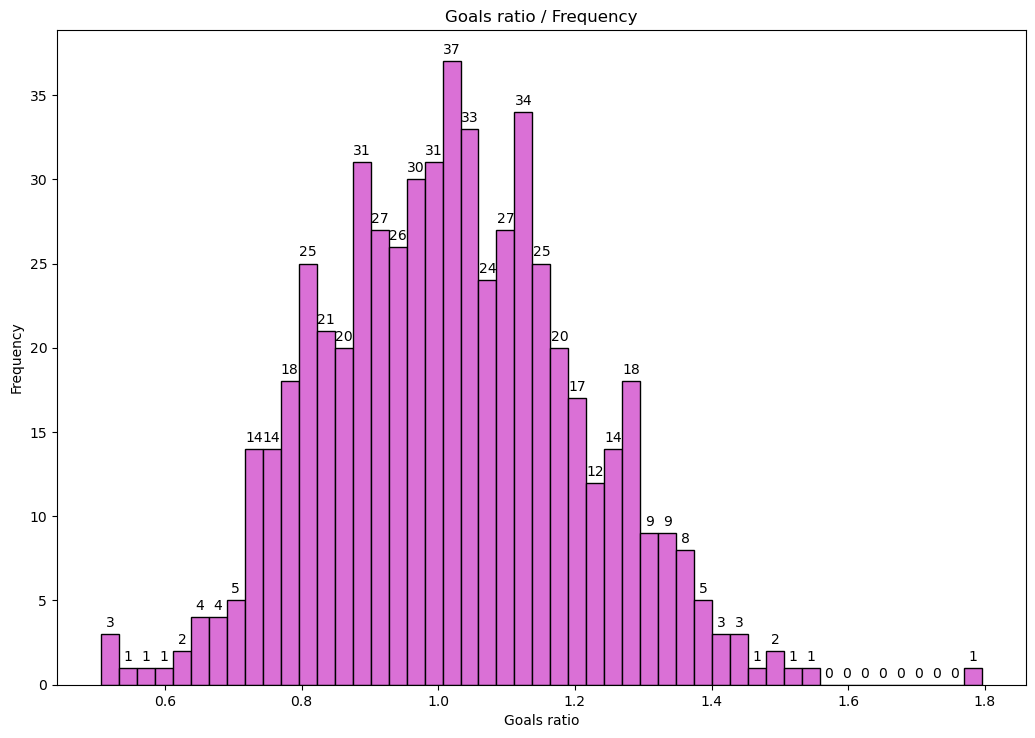

In [55]:
plt.figure(figsize=(12.5,8.5))
plt.clf
counts, bins, bars = plt.hist(df['goals_ratio'], bins = binr, color = 'orchid', edgecolor='black')
plt.ylabel('Frequency')
plt.xlabel('Goals ratio')
plt.title ('Goals ratio / Frequency')
plt.bar_label(bars, padding=3)
plt.show()

### Histogram of the variable using the square root rule

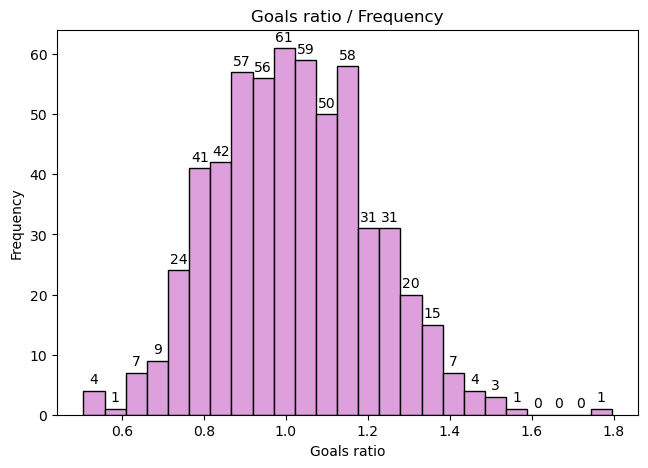

In [ ]:
plt.figure(figsize=(7.5,5))
plt.clf
counts, bins, bars = plt.hist(df['goals_ratio'], bins = binn, color='plum', edgecolor='black')
plt.ylabel('Frequency')
plt.xlabel('Goals ratio')
plt.title ('Goals ratio / Frequency')
plt.bar_label(bars, padding=3)
plt.show()

#najvise timova je izjednaceno na sredini, dok sa leve i desne str imamo
#levo -losije timove (SJ Sharks), primili vise golova nego sto su dali i obrnuto sa desne str (DT Red Wings).

# `victory_percentage`

Similar to the analysis of the variable `goals_ratio`, we will conduct an exploratory analysis of `victory_percentage` by following these steps:  
- Determine the basic descriptive statistics, such as the mean, median, standard deviation, minimum, and maximum.  
- Examine the distribution of the variable by using a histogram to better understand its characteristics.  
- Check if there are any obvious subgroups of teams within the variable under analysis that could be identified based on specific criteria, such as the range of the variable's values.

### Descriptive Statistics

In [31]:
wins_pt = df['victory_percentage'].describe()
wins_pt

count    582.000000
mean       0.458519
std        0.102237
min        0.119000
25%        0.390000
50%        0.463000
75%        0.534000
max        0.756000
Name: victory_percentage, dtype: float64

### Distribution

Here we will create the distribution of the variable, but we won't be doing it in two versions. Instead, we will choose a different, arbitrary number of intervals.

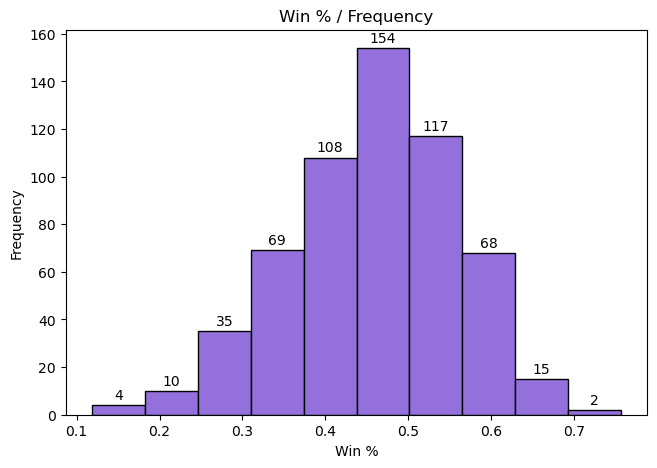

In [32]:
plt.figure(figsize=(7.5,5))
plt.clf
counts, bins, bars = plt.hist(df['victory_percentage'], bins = 10, color='mediumpurple',edgecolor='black')
plt.ylabel('Frequency')
plt.xlabel('Win %')
plt.title ('Win % / Frequency')
plt.bar_label(bars, padding=2)
plt.show()

# `goals_ratio` vs `victory_percentage`

We have already analyzed `goals_ratio` and `victory_percentage` as two separate variables. Now, our task is to analyze them together to identify potential interdependencies between them.  
  
In this step, we will perform the following exercises:  
- Before starting the analysis, let’s consider whether these variables might be dependent or independent of each other. What kind of relationship can be expected based on their business descriptions?  
- We will create a scatterplot to visually represent the dependencies between these variables.  
- We will determine the relationship between the variables based on the scatterplot.  
- We will analyze the scatterplot to identify any outliers, paying special attention to their common distribution.

## Scatterplot of Variables

Now let's create a scatterplot for the two analyzed variables, `goals_ratio` and `victory_percentage`. After completing this step, let's answer the following questions:  
- What is the relationship between the variables `goals_ratio` and `victory_percentage`?  
- Can any outliers be identified in the plot? If so, what criteria were used to identify them?

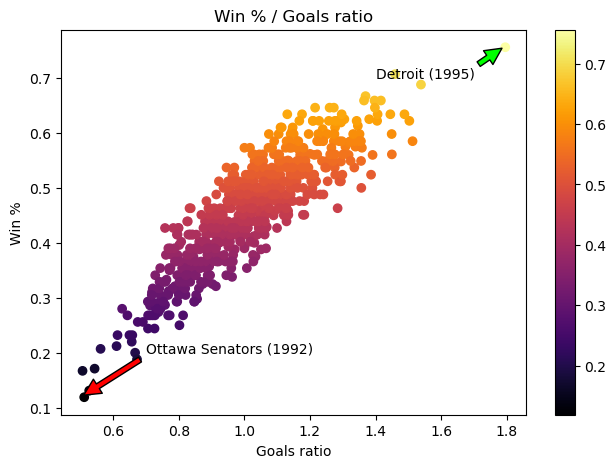

In [42]:
plt.figure(figsize=(7.5,5))
plt.clf
x=plt.scatter(df['goals_ratio'],
              df['victory_percentage'],
              c = df['victory_percentage'],
              cmap = "inferno"
              )
plt.colorbar()
plt.ylabel('Win %')
plt.xlabel('Goals ratio')
plt.title ('Win % / Goals ratio')
plt.annotate('Detroit (1995)',
            xy=(1.79, 0.756),
            xytext=(1.4, 0.7),
            arrowprops=dict(facecolor='lime', shrink=0.05))
plt.annotate('Ottawa Senators (1992)',
            xy=(0.5, 0.119),
            xytext=(0.7, 0.2),
            arrowprops=dict(facecolor='red', shrink=0.05))
plt.show()

space for chart analysis notes
Korelacija pobeda i datih golova je u pozitivnoj i jakoj vezi. Direktno su povezane (veci br datih golova naspram primljenih znaci i veci br pobeda) i obrnuto.
Povrsna gugl pretraga kaze - OT Senators - prva, povratnicka sezona u modernoj eri (nakon što fransiza nije postojala decenijama), usli su u ligu sa potpuno novim, neuigranim timom sa drafta i eto. Nije im se dalo.
DT Red Wings - Gugl kaze da im je ovo bila legendarna sezona sto zbog "Ruske petorke" koji su neverovatno igrali - neki kazu najbolja petorka sporta -  i promenili stil igre, videli smo da im je procenat pobeda cca 76% (win% = 75.6%) i davali su u proseku duplo vise golova nego sto su primali (goal_ratio = 1.79) i 3. najbitnija stvar - sezona je trajala krace posto je bio strajk u ligi tj umesto 82 odigralo se 48 utakmica, a oni pobedili 33.

If we have identified outlying observations at an earlier stage of analysis, let's now examine these specific cases. We will focus on outliers concerning the variables `goals_ratio` and `victory_percentage` to understand what features distinguish them.

The following steps should be taken for analysis:
1. Identify the specific outlying observations that were detected earlier.
2. Analyze the characteristics of these observations, paying attention to their values for the variables `goals_ratio` and `victory_percentage`.
3. Try to understand what might have caused their outlying nature. Are these instances of anomalies, or could they be the result of natural fluctuations in the data?

In [34]:
corr_gw = df['goals_ratio'].corr(df['victory_percentage'])
float(round(corr_gw,3))

0.881

NESRECNICI i MALERI :((((

1. Maleri koji su postizali vise golova nego sto su primali, a ipak imali los procenat pobeda.

In [37]:
maleri = df[(df['goals_ratio'] > 1) & (df['victory_percentage']<0.40)]
maleri.sort_values(by = 'victory_percentage')

,team,season,victories,defeats,overtime_defeats,victory_percentage,scored_goals,received_goals,goal_difference,goals_ratio
98,Dallas Stars,1994,17,23,0,0.354,136,135,1,1.007407
356,Minnesota Wild,2003,30,29,3,0.366,188,183,5,1.027322
116,Vancouver Canucks,1994,18,18,0,0.375,153,148,5,1.033784
218,San Jose Sharks,1998,31,33,0,0.378,196,191,5,1.026178
1,Buffalo Sabres,1990,31,30,0,0.388,292,278,14,1.050360
234,Edmonton Oilers,1999,32,26,8,0.390,226,212,14,1.066038


Najmanji broj pobeda, a gol razlika u +.

In [38]:
maleri.sort_values(by = 'goal_difference')

,team,season,victories,defeats,overtime_defeats,victory_percentage,scored_goals,received_goals,goal_difference,goals_ratio
98,Dallas Stars,1994,17,23,0,0.354,136,135,1,1.007407
116,Vancouver Canucks,1994,18,18,0,0.375,153,148,5,1.033784
218,San Jose Sharks,1998,31,33,0,0.378,196,191,5,1.026178
356,Minnesota Wild,2003,30,29,3,0.366,188,183,5,1.027322
1,Buffalo Sabres,1990,31,30,0,0.388,292,278,14,1.050360
234,Edmonton Oilers,1999,32,26,8,0.390,226,212,14,1.066038


Dalas igrao za dlaku svaku utakmicu.

In [64]:
losers_season=df.loc[df.groupby('season')['victory_percentage'].idxmin()]
losers_season.sort_values(by = 'victory_percentage', ascending = True).head()

,team,season,victories,defeats,overtime_defeats,victory_percentage,scored_goals,received_goals,goal_difference,goals_ratio
56,Ottawa Senators,1992,10,70,0,0.119,202,395,-193,0.511392
82,Ottawa Senators,1993,14,61,0,0.167,201,397,-196,0.506297
225,Atlanta Thrashers,1999,14,57,4,0.171,170,313,-143,0.543131
108,Ottawa Senators,1994,9,34,0,0.188,117,174,-57,0.672414
15,Quebec Nordiques,1990,16,50,0,0.200,236,354,-118,0.666667


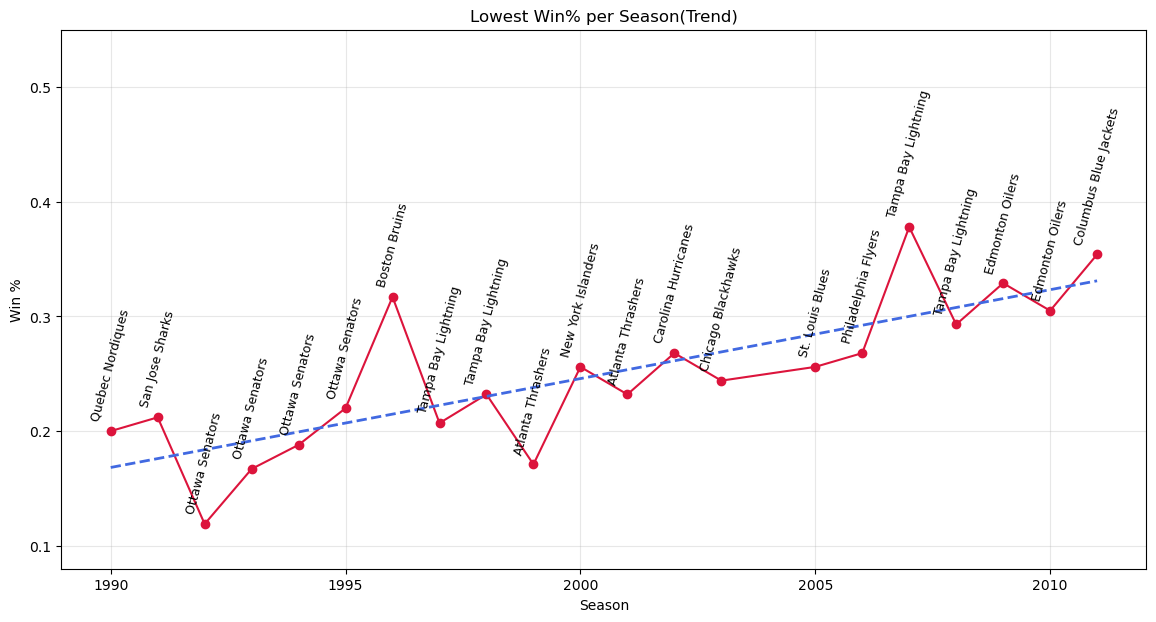

In [72]:
losers_season = losers_season.sort_values(by='season')

plt.figure(figsize=(14, 7))
plt.plot(losers_season['season'], losers_season['victory_percentage'], marker='o', color='crimson')

m, b = np.polyfit(losers_season['season'], losers_season['victory_percentage'], 1)
plt.plot(losers_season['season'], m * losers_season['season'] + b, color='royalblue', linestyle='--', linewidth=2)

for index, row in losers_season.iterrows():
    plt.text(x=row['season'], 
             y=row['victory_percentage'] + 0.01, 
             s=row['team'], 
             fontsize=9, 
             rotation=75, 
             ha='center')

plt.xlabel('Season')
plt.ylabel('Win %')
plt.title('Lowest Win% per Season(Trend)')
plt.grid(True, alpha=0.3)
plt.ylim(0.08, 0.55) 
plt.show()

Dobro je, trend je pozitivan bez obzira sto je graf za sezonske gubitnike. Timovi sve bolje fejluju.
Povrsna gugl pretraga kaze kada sam pitala ko i dalje postoji:
Quebec Nordiques je prodat i preseljen 1995. i sada je to tim Colorado Avalanche.
Atlanta Trashers su ugaseni 2011 zbog finanskijskih problema i slabe posecenosti (u februaru je 26+ stepeni u Feniksu, ovo dodje kao odlazak na bazen, da se rashladis i oporavis od vrucine, jer led treba da se odrzava, ne razumem zasto nisu isli ljudi). UGLAVNOM, danas su Winnipeg Jets.
Ostali timovi su i dalje aktivni.

In [67]:
winner_season=df.loc[df.groupby('season')['victory_percentage'].idxmax()]
winner_season.sort_values(by = 'season', ascending = False)

,team,season,victories,defeats,overtime_defeats,victory_percentage,scored_goals,received_goals,goal_difference,goals_ratio
570,New York Rangers,2011,51,24,7,0.622,226,187,39,1.208556
550,Vancouver Canucks,2010,54,19,9,0.659,262,185,77,1.416216
521,Washington Capitals,2009,54,15,13,0.659,318,233,85,1.364807
464,Boston Bruins,2008,53,19,10,0.646,274,196,78,1.397959
442,Detroit Red Wings,2007,54,21,7,0.659,257,184,73,1.396739
405,Buffalo Sabres,2006,53,22,7,0.646,308,242,66,1.272727
382,Detroit Red Wings,2005,58,16,8,0.707,305,209,96,1.459330
352,Detroit Red Wings,2003,48,21,2,0.585,255,189,66,1.349206
332,Ottawa Senators,2002,52,21,1,0.634,263,182,81,1.445055
292,Detroit Red Wings,2001,51,17,4,0.622,251,187,64,1.342246


Najbolji timovi po sezoni za posmatrani period.
Povrsna Gugl pretraga: '99. je uvedeno pravilo da ako je utakmica neresena moraju da igraju produzetak od 5min, ali ako niko ne da gol u tih 5 min, utakmica je opet neresena (TIE). Poenta ovoga je sto ako izgubis u produzetku i dalje dobijes 1 poen, a pobednik 2. '05. je uvedeno pravilo da svaka utakmica mora biti resena, te su uveli penale.

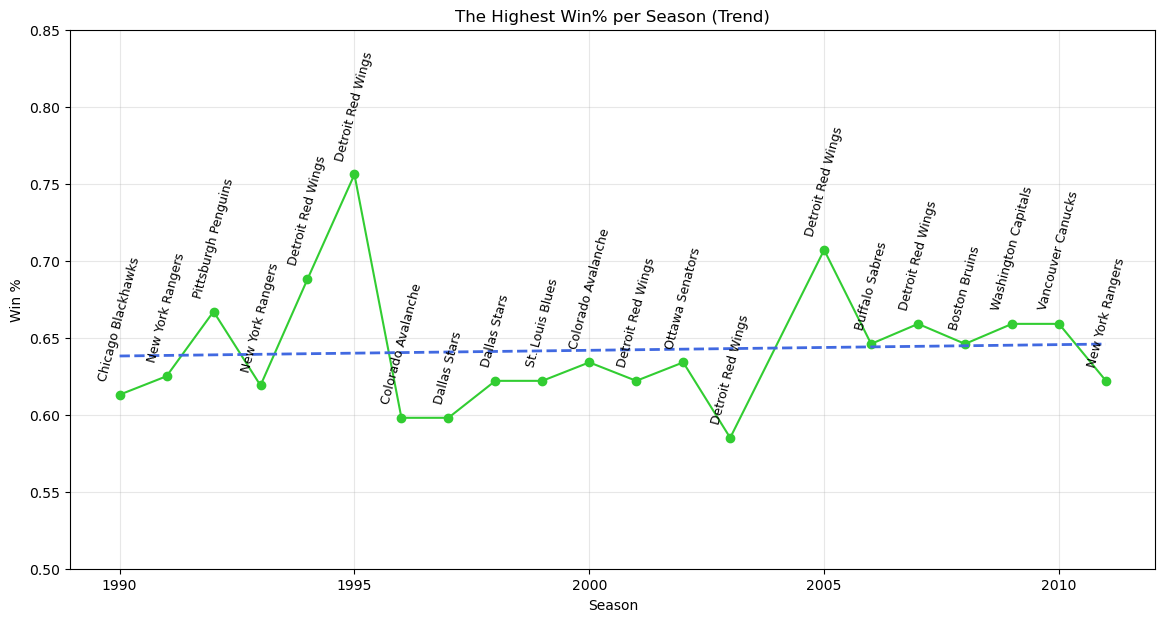

In [73]:
winner_season = winner_season.sort_values(by='season')

plt.figure(figsize=(14, 7))
plt.plot(winner_season['season'], winner_season['victory_percentage'], marker='o', color='limegreen', linestyle='-')

m, b = np.polyfit(winner_season['season'], winner_season['victory_percentage'], 1)
plt.plot(winner_season['season'], m * winner_season['season'] + b, color='royalblue', linestyle='--', linewidth=2)

for index, row in winner_season.iterrows():
    plt.text(x=row['season'], 
             y=row['victory_percentage'] + 0.01, 
             s=row['team'], 
             fontsize=9, 
             rotation=75, 
             ha='center')

plt.xlabel('Season')
plt.ylabel('Win %')
plt.title('The Highest Win% per Season (Trend)')
plt.grid(True, alpha=0.3)
plt.ylim(0.50, 0.85) 
plt.show()

Ako izuzmemo pojedine neverovatne sezone DT Red Wingsa (drze i najbolji 75.6% i najlosiji rezultat 58.5% na grafiku) za posmatrani period, trend je prilicno uprosecen na cca 63-66% pobeda po sezoni.

U principu, luzeri su postali dosta bolji, trend rasta je kod njih mnogo uocljiviji naspram pobednika. Takoreci, timovi se uprosecuju u smislu, da je sve manja razlika izmedju njih. Na kraju krajeva, svede se na to kome je bolji dan.

# Summary

In this notebook, we conducted a basic exploratory analysis of our dataset. The data was cleaned and then enriched with new variables, which we subjected to further analysis. The final step of this part is to save the processed data to a CSV file.  
  
**Let's save our data frame to the file:** `data/processed/hockey_teams.csv`, using a semicolon (`;`) as the column separator.

Next, in the following phase of our work, we will propose betting odds based on the analyzed historical data and discuss the results of this analysis.

### Writing the frame to the target location

- file name: `data/processed/hockey_teams.csv`,
- column separator: `;`,
- remember to disable index saving.

In [173]:
df.to_csv(r'C:\Users\stefa\Desktop\CodersLab - Pyton - DA\Workshop - Aleksandra\Data\processed/hockey_teams.csv', sep=';', index=False)

In [175]:
df_test = pd.read_csv(r'C:\Users\stefa\Desktop\CodersLab - Pyton - DA\Workshop - Aleksandra\Data\processed/hockey_teams.csv', sep=';', decimal='.')
df_test

,team,season,victories,defeats,overtime_defeats,victory_percentage,scored_goals,received_goals,goal_difference,goals_ratio
0,Boston Bruins,1990,44,24,0,0.550,299,264,35,1.132576
1,Buffalo Sabres,1990,31,30,0,0.388,292,278,14,1.050360
2,Calgary Flames,1990,46,26,0,0.575,344,263,81,1.307985
3,Chicago Blackhawks,1990,49,23,0,0.613,284,211,73,1.345972
4,Detroit Red Wings,1990,34,38,0,0.425,273,298,-25,0.916107
...,...,...,...,...,...,...,...,...,...,...
577,Tampa Bay Lightning,2011,38,36,8,0.463,235,281,-46,0.836299
578,Toronto Maple Leafs,2011,35,37,10,0.427,231,264,-33,0.875000
579,Vancouver Canucks,2011,51,22,9,0.622,249,198,51,1.257576
580,Washington Capitals,2011,42,32,8,0.512,222,230,-8,0.965217
